In [ ]:
from transformers import DetrForObjectDetection, DetrConfig, DetrImageProcessor, Trainer, TrainingArguments, ResNetConfig
from torch.utils.data import random_split
from dataset import DartsDataset
from torchvision import transforms
from PIL import Image, ImageDraw
from util import prepare_6_channel
import torch
from torchvision.datasets import CocoDetection
import numpy as np
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
id2label = {
    0: "right",
    1: "top",
    2: "left",
    3: "bottom",
    4: "dart",
}
label2id = {v: k for k, v in id2label.items()}

In [110]:
model = DetrForObjectDetection.from_pretrained(
    "facebook/detr-resnet-50", 
    auxiliary_loss=True, 
    num_queries=100,
    num_labels=5,  
    bbox_loss_coefficient=4.0,
    giou_loss_coefficient=1.0,
    giou_cost=0.0,
    eos_coefficient = 0.06,
    ignore_mismatched_sizes=True,
    id2label=id2label,
    label2id=label2id
    )
image_processor = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50", size={"shortest_edge": 768, "longest_edge": 768})
model.config

Some weights of the model checkpoint at facebook/detr-resnet-50 were not used when initializing DetrForObjectDetection: ['model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing DetrForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DetrForObjectDetection from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of DetrForObjectDetection were not initialized from the model checkpoin

DetrConfig {
  "activation_dropout": 0.0,
  "activation_function": "relu",
  "architectures": [
    "DetrForObjectDetection"
  ],
  "attention_dropout": 0.0,
  "auxiliary_loss": true,
  "backbone": "resnet50",
  "backbone_config": null,
  "backbone_kwargs": {
    "in_chans": 3,
    "out_indices": [
      1,
      2,
      3,
      4
    ]
  },
  "bbox_cost": 5,
  "bbox_loss_coefficient": 4.0,
  "class_cost": 1,
  "classifier_dropout": 0.0,
  "d_model": 256,
  "decoder_attention_heads": 8,
  "decoder_ffn_dim": 2048,
  "decoder_layerdrop": 0.0,
  "decoder_layers": 6,
  "dice_loss_coefficient": 1,
  "dilation": false,
  "dropout": 0.1,
  "encoder_attention_heads": 8,
  "encoder_ffn_dim": 2048,
  "encoder_layerdrop": 0.0,
  "encoder_layers": 6,
  "eos_coefficient": 0.06,
  "giou_cost": 0.0,
  "giou_loss_coefficient": 1.0,
  "id2label": {
    "0": "right",
    "1": "top",
    "2": "left",
    "3": "bottom",
    "4": "dart"
  },
  "init_std": 0.02,
  "init_xavier_std": 1.0,
  "is_encoder_dec

In [ ]:
prepare_6_channel(model)

In [126]:
for k, v in model.named_parameters():
    print(k, v.shape, v.requires_grad, v[0, :, :, 0])


model.backbone.conv_encoder.model.conv1.weight torch.Size([64, 6, 7, 7]) False tensor([[ 0.0133,  0.0041,  0.0223,  0.0232, -0.0009,  0.0036, -0.0800],
        [-0.0185, -0.0077, -0.0460, -0.0386,  0.0288,  0.0829, -0.0073],
        [-0.0183, -0.0101, -0.0635, -0.0280,  0.0258,  0.0730, -0.0064],
        [ 0.0133,  0.0041,  0.0223,  0.0232, -0.0009,  0.0036, -0.0800],
        [-0.0185, -0.0077, -0.0460, -0.0386,  0.0288,  0.0829, -0.0073],
        [-0.0183, -0.0101, -0.0635, -0.0280,  0.0258,  0.0730, -0.0064]])
model.backbone.conv_encoder.model.layer1.0.conv1.weight torch.Size([64, 64, 1, 1]) False tensor([[ 3.5144e-03],
        [ 3.9855e-02],
        [-2.4795e-02],
        [-2.7827e-02],
        [ 8.8871e-02],
        [-2.2322e-03],
        [-1.9144e-02],
        [-5.5382e-02],
        [ 5.7721e-02],
        [-2.4470e-02],
        [-9.0976e-03],
        [ 3.7905e-02],
        [-2.7061e-02],
        [ 7.5568e-09],
        [-5.4823e-03],
        [ 8.2370e-02],
        [-1.1916e-01],
  

IndexError: too many indices for tensor of dimension 1

In [69]:
dirs = [f'3D/scene/rendered/imgs_{i}' for i in range(6)]
dataset = DartsDataset(dirs=dirs, random_rescale=False, return_reference=True, is_synthetic=True)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

generator = torch.Generator().manual_seed(42)
train_dataset, test_dataset = random_split(dataset, [train_size, test_size], generator=generator)
len(train_dataset), len(test_dataset)

(19200, 4800)

torch.Size([1, 3, 768, 768])
torch.Size([1, 3, 768, 768])


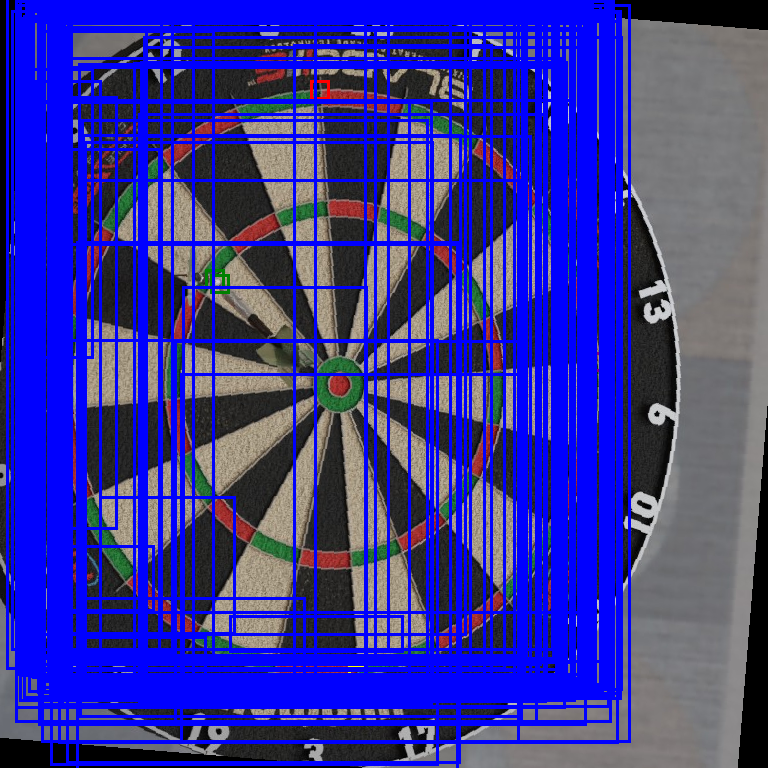

In [129]:
image, targets, reference = test_dataset[np.random.randint(len(test_dataset))]
inputs = image_processor(images=image, annotations=targets, return_tensors="pt", do_resize=False)
reference_inputs = image_processor(images=reference, return_tensors="pt", do_resize=False)
print(reference_inputs["pixel_values"].shape)
print(inputs["pixel_values"].shape)
inputs["pixel_values"] = torch.cat([inputs["pixel_values"], reference_inputs["pixel_values"]], dim=1)
boxes = (inputs.labels[0].boxes*768).round()
outputs = model(**inputs)

target_sizes = torch.tensor([image.size[::-1]])
results = image_processor.post_process_object_detection(outputs, threshold=0.1, target_sizes=target_sizes)[0]
draw = ImageDraw.Draw(image)
for i, target in enumerate(targets["annotations"]):
    box, category_id = target["bbox"], target["category_id"]
    x, y, w, h = box
    box = [x, y, x + w , y + h]
    color = ["purple", "red", "orange", "yellow", "green"]
    draw.rectangle(box, outline=color[min(i, len(color)-1)], width=3)
for i, box in enumerate(results["boxes"]):
    label= results["labels"][i].item()
    # print(label)
    draw.rectangle(box.tolist(), outline="blue", width=3)
image

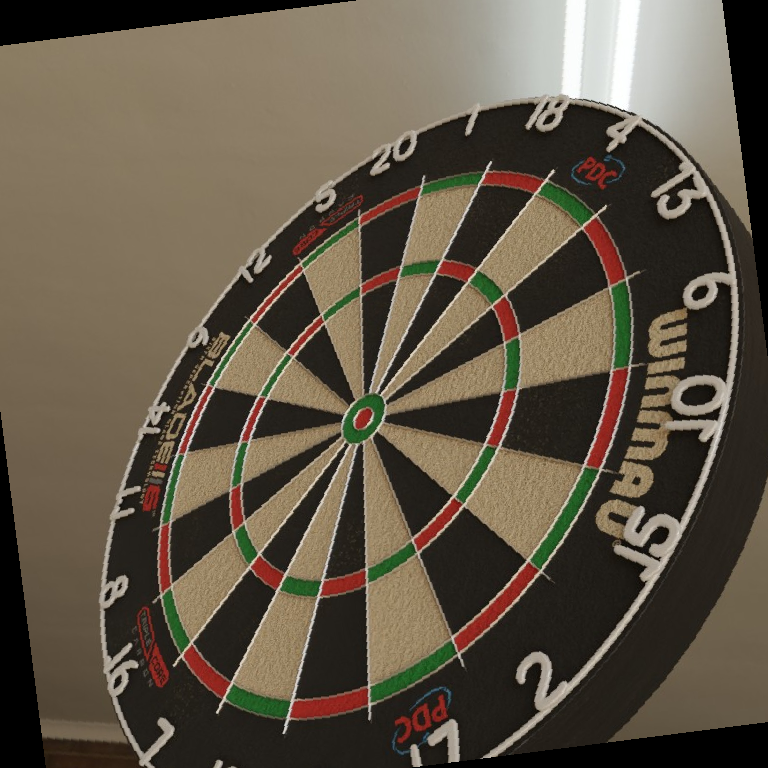

In [45]:
reference

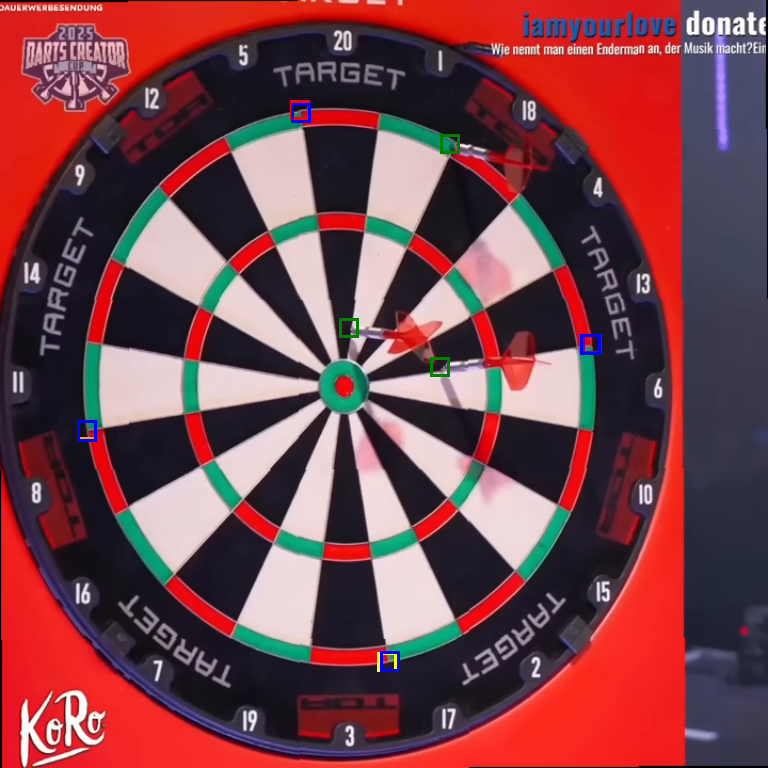

In [ ]:
dirs = [f'my_unlabelled/vids/frames_000{i}' for i in range(8)]
val_dataset = DartsDataset(dirs=dirs, random_rescale=False, resize_to=768)

index = np.random.randint(len(val_dataset))
image, targets = val_dataset[index]
# image = Image.open("thommy/_IMG0813.jpg")
# image = image.resize((768, 768))
inputs = image_processor(images=image, annotations=targets, return_tensors="pt", do_normalize=True)

boxes = (inputs.labels[0].boxes*768).round()
outputs = model(**inputs)

target_sizes = torch.tensor([image.size[::-1]])
results = image_processor.post_process_object_detection(outputs, threshold=0.75, target_sizes=target_sizes)[0]
draw = ImageDraw.Draw(image)
for i, target in enumerate(targets["annotations"]):
    box, category_id = target["bbox"], target["category_id"]
    x, y, w, h = box
    box = [x, y, x + w , y + h]
    color = ["purple", "red", "orange", "yellow", "green"]
    draw.rectangle(box, outline=color[min(i, len(color)-1)], width=3)
for i, box in enumerate(results["boxes"]):
    label= results["labels"][i].item()
    draw.rectangle(box.tolist(), outline="blue", width=3)
image